In [2]:
import pandas as pd
import pypsa
import numpy as np
import xarray as xr
from pathlib import Path
from itertools import permutations
from typing import Optional, Dict, Any
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly
import seaborn as sb
import logging
from pathlib import Path
import sys
from typing import Optional, Dict, Any
import gc

---
---
## <span style=color:yellow> **MARTA'S IMPLEMENTATION**
---
---

### <span style=color:pink> **Re-organise data(frames) needed for the project**

#### **Data centre demand profiles**

In [ ]:
# df_dc_demand_profile = pd.read_csv("../data/data_centres/ukpn-data-centre-demand-profiles.csv")
# # df_dc_demand_profile.head()
# # assigning df column names to something shorter for ease
# UTIL = "hh_utilisation_ratio"
# DC_NAME = "anonymised_data_centre_name"
# DC_TYPE = "dc_type"
# VOLT = "cleansed_voltage_level"
# TIME = "utc_timestamp"
# # ordering voltage -> low to extra-high
# VOLT_ORDER = ["Low Voltage Import", "High Voltage Import", "Extra-High Voltage Import"]
# # convert to date/time
# df_dc_demand_profile[TIME] = pd.to_datetime(df_dc_demand_profile[TIME], utc=True)

#### **Population data**

In [22]:
# https://www.worldometers.info/population/largest-cities-in-uk/ with easting/northing
df_population = pd.read_csv("../data/data_centres/uk_largest_cities.csv")

df_population = df_population.drop(columns=['Global Rank'])
df_population.head()

,Rank,Urban Area,Population Estimate (2025),1 Year Change (over 2024),Land Area (Km2),Density (P/Km2),Projections (2030),Projections (2050),Easting,Northing
0,1,London,"10,416,420",0.82%,"1,646","6,328","10,766,831","11,868,905",530029,180380
1,2,Birmingham,"2,631,757",0.54%,671,"3,922","2,689,574","2,810,468",407540,287592
2,3,Manchester,"2,535,427",0.38%,741,"3,422","2,567,727","2,638,194",383997,398258
3,4,Liverpool,"1,227,470",0.53%,369,"3,326","1,241,135","1,254,523",334179,390634
4,5,Leeds,"1,065,607",0.45%,323,"3,299","1,086,815","1,109,261",429796,433927


#### **FES data**

In [23]:
url = ("https://api.neso.energy/dataset/2c15c755-d8fe-4229-9169-3b6dd7c88fec/"
       "resource/300c07b9-baeb-4411-bc40-987cbb4aec0b/download/fes2025_ed1_v006.csv")
df_neso_energy_demand = pd.read_csv(url)

df_fes_filtered = df_neso_energy_demand[
    (df_neso_energy_demand['Data item'] == 'Data Centre Demand') |
    (df_neso_energy_demand['Data item'] == 'GBFES System Demand: Total')
]
df_fes_filtered

,Aggregation Level,Data item,Unit,Pathway,Fuel,Peak/ Annual/ Minimum,2023,2024,2025,2026,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,1,GBFES System Demand: Total,GWh,Hydrogen Evolution,Electricity,Annual [Fiscal],286780.0,289650.0,293394.0,297512.0,...,629181.0,658165.0,691892.0,720585.0,732957.0,748081.0,770705.0,778236.0,795993.0,797120.0
1,1,GBFES System Demand: Total,GWh,Electric Engagement,Electricity,Annual [Fiscal],286780.0,289650.0,291698.0,296073.0,...,644531.0,672190.0,694708.0,709671.0,724440.0,737930.0,752313.0,766439.0,776227.0,784736.0
2,1,GBFES System Demand: Total,GWh,Falling Behind,Electricity,Annual [Fiscal],286780.0,289650.0,295231.0,298512.0,...,450011.0,464557.0,477519.0,490691.0,504316.0,516137.0,526834.0,537853.0,548276.0,558750.0
3,1,GBFES System Demand: Total,GWh,Holistic Transition,Electricity,Annual [Fiscal],286780.0,289650.0,290891.0,294991.0,...,582761.0,602352.0,621073.0,635458.0,654296.0,670284.0,681236.0,691034.0,700725.0,705223.0
4,1,GBFES System Demand: Total,GWh,Ten Year Forecast,Electricity,Annual [Fiscal],286780.0,289650.0,292075.0,295108.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,5,Data Centre Demand,GWh,Hydrogen Evolution,Electricity,Annual [Fiscal],7400.0,7538.0,8651.0,9735.0,...,39705.0,41216.0,42709.0,44132.0,45430.0,46664.0,47856.0,49012.0,50139.0,51242.0
121,5,Data Centre Demand,GWh,Electric Engagement,Electricity,Annual [Fiscal],7400.0,7565.0,9343.0,10912.0,...,56831.0,58855.0,60678.0,62329.0,63884.0,65356.0,66757.0,68098.0,69352.0,70562.0
122,5,Data Centre Demand,GWh,Falling Behind,Electricity,Annual [Fiscal],7400.0,7518.0,8014.0,8400.0,...,24696.0,25407.0,26070.0,26704.0,27357.0,27986.0,28594.0,29184.0,29766.0,30334.0
123,5,Data Centre Demand,GWh,Holistic Transition,Electricity,Annual [Fiscal],7400.0,7565.0,9259.0,10864.0,...,51867.0,53796.0,55559.0,57165.0,58687.0,60136.0,61519.0,62845.0,64101.0,65317.0
124,5,Data Centre Demand,GWh,Ten Year Forecast,Electricity,Annual [Fiscal],7400.0,7738.0,8129.0,8929.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Create sub-functions to complete easy tasks within main functions**

In [24]:
def _nearest_bus(base_network: pypsa.Network, easting, northing, nearest_n_buses = False):
    '''
    This function finds the nearest bus for the specified location (easting / northing).
    
    Args:
        - base network: the pypsa baseline network to add data centres to
        - easting, northing: easting and northing of the preferred location
        - nearest_n_buses: optional — returns a list of buses closest to the point
    
    Returns:
        - bus that has to closest to the specified location
    '''

    # get AC buses only, do not allow for attaching onto the HVDC import/export buses
    ac_bus = base_network.buses[(base_network.buses.carrier == "AC") & 
                                (~base_network.buses.index.str.contains("HVDC|external", case=False))
                                ]

    # find the distance between selected point and the AC buses
    distance = np.sqrt((ac_bus.x-easting)**2 + (ac_bus.y-northing)**2)
    # select the one with minimum distance
    nearest_bus = distance.idxmin()
    if nearest_n_buses:
        return distance.sort_values(ascending = True)
    
    return nearest_bus

def _get_timestep_hours(index: pd.DatetimeIndex, default: float = 1) -> float:
    '''
    This function takes the snapshot of selected time and converts that into hours. 
    Based on PyPSA-GB.
    '''
    # return 1 if time 
    if index is None or len(index) < 2:
        return default
    delta_hours = (index[1] - index[0]).total_seconds() / 3600.0

    return delta_hours if delta_hours > 0 else default

def _get_dc_demand_profile(return_mean_utilisation = False):
    '''
    This function returns the demand profile (per half-hourly timestep), based on the UKPN data.
    
    Reads data centre data -> renames utilisation/date&time columns -> converts to numeric/date_time ->
    -> group by date/time step -> keep utilisation column -> for each timestep preserve the mean utilisation of all 
    the 94 data centre utilisation for that given timestep -> sort index ---> *save as df_dc_demand_profile_dt*
    
    Returns:
        - demand_profile_per_dt: returns the full demand profile, averaged across 94 data centres in the UKPN region, 
        for each half-hour time-step 01-01-2023–26-04-2026.
        - mean utilisation: OPTIONAL, instead of returning the demand profile for each timestep, returns the overall mean utilisation value.
    '''
    df_dc_demand_profile = pd.read_csv("../data/data_centres/ukpn-data-centre-demand-profiles.csv")
  
    # assigning df column names to something shorter for ease
    UTIL = "hh_utilisation_ratio"
    TIME = "utc_timestamp"
    
    # convert to date/time
    df_dc_demand_profile[UTIL] = pd.to_numeric(df_dc_demand_profile[UTIL], errors="coerce")
    df_dc_demand_profile[TIME] = pd.to_datetime(df_dc_demand_profile[TIME], errors="coerce", utc=True)

    # per time-step, all data centre-averaged utilisation
    demand_profile_per_dt = df_dc_demand_profile.groupby(TIME)[UTIL].mean().sort_index()

    if return_mean_utilisation:
        mean = demand_profile_per_dt.mean()
        return mean

    return demand_profile_per_dt

def _get_total_dc_demand_FES_gw(year: int, 
                                scenario: str, 
                                return_GWh = False, 
                                mean_utilisation = 0.55):
    '''
    This function takes the total load demand - wether it's from historic data or Future Energy Scenario (FES),
    and calculates the DC demand as a fraction of the total demand.

    Args:
        - year: year the capacity is to predicted for
        - total_gwh: GB's total load demand in GWh
        - fraction: assumed % of the total demand that data centres account for (0.9–2%, predicted). Default value: 2% = 0.02
    Returns:
        - total_dc_gw: the total capacity of data centres, as predicted by FES, in GW
        - total_dc_gwh: 
    '''
    # list available scenarios
    scenario_list = ['Hydrogen Evolution', 'Holistic Transition', 'Falling Behind', 'Electric Engagement']
    if scenario not in scenario_list:
        raise NameError("Wrong scenario name. Available scenarios:", scenario_list)
    
    elif year <= 2024 or year > 2050:
        raise ValueError("This is a module for Future Scenarios. Enter year > 2024, up to 2050.")
    else:
        df_fes = pd.read_csv("../data/data_centres/fes2025_ed1_v006.csv")

        # take the data from column matching year choice & row = desired scenario for data centre demand
        total_dc_gwh = float(df_fes[str(year)][
            (df_fes['Data item'] == 'Data Centre Demand') &
            (df_fes['Pathway'] == scenario)].iloc[0])
        # 8760 hours in a year (non-leap)
        total_dc_gw = total_dc_gwh / 8760 / mean_utilisation

    # possible to get the GWh reading directly, if preferred
    if return_GWh:
        return total_dc_gwh

    return total_dc_gw


In [25]:
def _convert_DC_demand_profile_to_GWh(total_dc_capacity_gw: float):
    '''
    This function converts the peak data centre capacity (GW) to the demand time series (GWh) and total demand (GWh).
    Args:
        - total_dc_capacity_gw: Peak data centre capacity (GW)
    Returns:
        - dc_time_series_demand_gwh: demand in GWh as half-hourly time series
        - total_dc_demand_gwh: total data centre demand over selected period of time
    '''

    # get the half-hourly demand profile
    demand_profile_per_dt = _get_dc_demand_profile()
    mean_utilisation = demand_profile_per_dt.mean()

    # scale the demand profile by expected peak demand
    dc_demand_per_dt_gw = total_dc_capacity_gw * demand_profile_per_dt

    timestep_hours = _get_timestep_hours(dc_demand_per_dt_gw.index)
    dc_time_series_demand_gwh = dc_demand_per_dt_gw * timestep_hours
    total_dc_demand_gwh = total_dc_capacity_gw  * mean_utilisation * 8760

    return dc_time_series_demand_gwh, total_dc_demand_gwh

def _get_total_dc_demand_MANUAL_gw(year: int, dc_prediction_2030_gw = 6.0):
    '''
    This function predicts a compound increase in DC capacity, based on the prediction made for the 
    2025 -> 2030 increase (1.6 GW -> 6.0 GW).
    This load will be added on top of the overall FES-predicted load / demand.
    Args:
        - year: a year which you want to predict the capacity for
        - dc_prediciton_20230_gw: used to calculate rate; assumed to be the current 6.0 GW by default, 
            but can be set to a more pessimistic (4.0 GW) or optimistic (8.0 GW)
            scenario to affect the rate and predict pessimistic/optmistic future scenarios overall.
    Returns:
        - total_dc_gw: the total capacity of the data centres
    '''
    
    # 6.0 (GW planned for 2030) = 1.6 (GW as of 2025) * (1+rate)**5  -> rate = (6.0/1.6)**1/5 - 1
    rate = (dc_prediction_2030_gw / 1.6) ** (1/5) - 1 
    total_dc_gw = 1.6 * (1+rate)**(year-2025)

    return total_dc_gw

---
---
## <span style="color:yellow">       **Create functions for the main workflow** </span>
---
---

#### **Allocation - north**

In [37]:
def allocate_north_scotland(total_dc_gw: float, 
                            base_network: pypsa.Network, 
                            # logger,  
                            single_dc_mw: float = 300) -> pd.Series:
    '''
    Allocation model placing ALL specified capacity in the North of Scotland as close to 290000, 870000 point (easting, northing) as possible.
    The model selectes n closest buses to place DCs on, where n is the total number of DCs.

    Args:
        - total_dc_gw: the total NEW data centre capacity
        - base_network: the base pypsa network, data centres (amongst other components) are being added on to
        - single_dc_mw: assumed size of a single data centre, in MW. Data centres won't have exactly this capcity, 
        but rather this + the evenly distributed remaining capacity after calculating the total number of DCs - rounding down the total capacity / single_dc_mw
    Returns:
        - dc_allocation: the allocated DC load per bus
    '''


    # number of full-capacity data centres that fit into the total capcity specified
    num_dc = int(np.floor(total_dc_gw * 1000 / single_dc_mw))
    print(f"Number of buses on the network: {len(base_network.buses)}")
    while num_dc > 0.5*len(base_network.buses):
        single_dc_mw += 200
        num_dc = int(np.floor(total_dc_gw * 1000 / single_dc_mw))
        print(f"Too many data centres to place on various buses.\n"
              f"Increasing single data centre capacity to {single_dc_mw:.2f} MW.\n")
        # logger.info(f"Too many data centres to place on various buses."
        #             f"Increasing single data centre capacity to {single_dc_mw:.2f} MW.")

    # total number of data centres added - +1 if total caapcity not divisible by single_dc_mw
    new_dc_mw = round(total_dc_gw * 1000 / num_dc, 2)

    # the list of available buses closest to the selected point in north of scotland, 
    # sorted by distance (closest -> furthest)
    bus_list = _nearest_bus(base_network, 290000, 870000, nearest_n_buses=True)
    bus_list = bus_list.head(num_dc)  # keeping only however many buses have data centres added on to them

    # set initial state of the dc capacity on buses - 0.0
    dc_allocation = pd.Series(0.0, index = base_network.buses.index)
    dc_allocation.loc[bus_list.index[:num_dc]] = new_dc_mw # assign DC capacities only to the closest n buses
    
    print(f"Allocated {dc_allocation.sum():.1f} MW in the north of Scotland ONLY ({num_dc} DCs of {new_dc_mw} MW).\n")
    
    return dc_allocation



In [4]:
test_network = pypsa.Network("../resources/network/Martas_Q3_reduced_2030.nc").copy()

INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'Martas_Q3_reduced_2030 (Full)' has buses, carriers, generators, lines, links, loads, storage_units, stores


In [7]:
test_capacities_gw = [6,10,20]

In [29]:
def test_scotland(base_network=test_network, test_capacities_gw=test_capacities_gw):
    for cap in test_capacities_gw:
        print(f"Test capacity: {cap} GW")
        allocate_north_scotland(base_network=base_network,
                                total_dc_gw=float(cap))
        
    

In [38]:
test_scotland()

Test capacity: 6 GW
Number of buses on the network: 39
Too many data centres to place on various buses.
Increasing single data centre capacity to 500.00 MW.

Allocated 6000.0 MW in the north of Scotland ONLY (12 DCs of 500.0 MW).

Test capacity: 10 GW
Number of buses on the network: 39
Too many data centres to place on various buses.
Increasing single data centre capacity to 500.00 MW.

Too many data centres to place on various buses.
Increasing single data centre capacity to 700.00 MW.

Allocated 10000.1 MW in the north of Scotland ONLY (14 DCs of 714.29 MW).

Test capacity: 20 GW
Number of buses on the network: 39
Too many data centres to place on various buses.
Increasing single data centre capacity to 500.00 MW.

Too many data centres to place on various buses.
Increasing single data centre capacity to 700.00 MW.

Too many data centres to place on various buses.
Increasing single data centre capacity to 900.00 MW.

Too many data centres to place on various buses.
Increasing single 

#### **Allocation - current split**

In [ ]:
def allocate_current_split_scaled(total_dc_gw: float, base_network: pypsa.Network, logger, single_dc_mw: float=300) -> pd.Series:
    '''
    This scenario takes into account the current capacity split across the country and keeps the 
    exact ratio of the capacities across regions: 
        - Scotland + North East + North West = 99 MW; 
        - Yorkshire and the Humber + Midlands + Wales = 194; 
        - London = 1,048; 
        - South West + South East + East = 225.

    Args:
        - total_dc_gw: the total NEW data centre capacity
        - base_network: the base pypsa network, data centres (amongst other components) are being added on to
        - single_dc_mw: assumed size of a single data centre, in MW. Data centres won't have exactly this capcity, 
        but rather this + the evenly distributed remaining capacity after calculating the total number of DCs - rounding down the total capacity / single_dc_mw
    Returns:
        - dc_allocation: the allocated DC load per bus
    '''
    # values based on: 
    # https://www.gov.uk/government/publications/estimate-of-data-centre-capacity-great-britain-2024/estimate-of-data-centre-capacity-great-britain-2024
    total_current_mw = 1566
    scotland_fraction = 99 / total_current_mw
    midlands_fraction = 194 / total_current_mw
    london_fraction = 1048 / total_current_mw
    england_fraction = 225 / total_current_mw

    # create lists of fractions, eastings and northings (same order)
    fractions = [scotland_fraction, midlands_fraction, london_fraction, england_fraction]
    eastings = [290000, 430000, 530000, 450000]
    northings = [870000, 400000, 180000, 170000]

    # initialise for the loop
    dc_allocation = pd.Series(0.0, index = base_network.buses.index)
    total_num_dc = 0
    dc_mw = []

    for i, fraction in enumerate(fractions):
        current_mw = total_dc_gw * 1000 * fraction

        if current_mw > single_dc_mw:
            num_dc = int(np.floor(current_mw / single_dc_mw ))

            # this is to prevent from too many data centres being placed
            # (possibly even more than there are buses available)   
            while num_dc > 0.5*len(base_network.buses):
                    single_dc_mw += 200
                    num_dc = int(np.floor(total_dc_gw * 1000 / single_dc_mw))

            new_dc_mw = round(current_mw / num_dc, 2)
        else: 
            new_dc_mw = round(current_mw, 2)
            num_dc = 1
        
        bus_list = _nearest_bus(base_network, eastings[i], northings[i], nearest_n_buses=True)
        bus_list = bus_list.head(num_dc)

        already_used = (dc_allocation.loc[bus_list.index[:num_dc]] != 0.0).any()
        if already_used:
            print(f"Warning: bus overlap detected in region {i}, adding to existing allocation")
        dc_allocation.loc[bus_list.index[:num_dc]] += new_dc_mw # assign DC capacities only to the closest n buses
        
        total_num_dc =+ num_dc
        dc_mw.append(new_dc_mw)
        print(f"Allocated {new_dc_mw * num_dc:.2f} MW ({num_dc} DC(s) of {new_dc_mw} MW).")
    
    print(f"Allocated {dc_allocation.sum():.2f} MW across the  ({total_num_dc} DCs of {dc_mw} MW).")
    
    return dc_allocation

#### **Allocation - population**

In [ ]:
def allocate_population_density_weighted(total_dc_gw: float, base_network: pypsa.Network, logger, single_dc_mw: float = 300) -> pd.Series:
    '''
    This scenario takes into account the highest population density points across the UK 
    and places the data centre capacities ~proportionally at those locations:
        - London 6 first data centres
        - Birmingham 7th & 8th DC
        - Manchester 9th & 10th DC
        - remaining DCs 1 per city

    Args:
        - total_dc_gw: the total NEW data centre capacity
        - base_network: the base pypsa network, data centres (amongst other components) are being added on to
        - single_dc_mw: assumed size of a single data centre, in MW.
    Returns:
        - dc_allocation: the allocated DC load per bus
    '''
    df_population = pd.read_csv("../data/data_centres/uk_largest_cities.csv")
    df_population = df_population.drop(columns=['Global Rank'])

    eastings = df_population["Easting"].tolist()
    northings = df_population["Northing"].tolist()

    dc_allocation = pd.Series(0.0, index=base_network.buses.index)
    total_num_dc = int(np.floor(total_dc_gw * 1000 / single_dc_mw))

    # this is to prevent from too many data centres being placed
    # (possibly even more than there are buses available)
    while total_num_dc >= 0.5*len(base_network.buses):
        single_dc_mw += 200
        total_num_dc = int(np.floor(total_dc_gw * 1000 / single_dc_mw))

    new_dc_mw = round(total_dc_gw * 1000 / total_num_dc, 2)

    # if <= 6 -> London
    if total_num_dc <= 6:
        print('6')
        bus_list = _nearest_bus(base_network, eastings[0], northings[0], nearest_n_buses=True)
        bus_list = bus_list.head(total_num_dc)
        dc_allocation.loc[bus_list.index] += new_dc_mw

    # if <= 8 -> 6 in London, then 2 in Birmingham
    elif total_num_dc <= 8:
        print('8')
        num_dc = [6, 2]
        for i in range(0, 2):
            bus_list = _nearest_bus(base_network, eastings[i], northings[i], nearest_n_buses=True)
            bus_list = bus_list.head(num_dc[i])
            already_used = (dc_allocation.loc[bus_list.index] != 0.0).any()
            if already_used:
                print(f"Warning: bus overlap detected in region {i}, adding to existing allocation")
            dc_allocation.loc[bus_list.index] += new_dc_mw

    # if <= 10 -> 6 in London, 2 in Birmingham, 2 in Manchester
    elif total_num_dc <= 10:
        print('10')
        num_dc = [6, 2, 2]
        for i in range(0, 3):
            bus_list = _nearest_bus(base_network, eastings[i], northings[i], nearest_n_buses=True)
            bus_list = bus_list.head(num_dc[i])
            already_used = (dc_allocation.loc[bus_list.index] != 0.0).any()
            if already_used:
                print(f"Warning: bus overlap detected in region {i}, adding to existing allocation")
            dc_allocation.loc[bus_list.index] += new_dc_mw

    else:
        num_dc = [6, 2, 2] + [1] * (total_num_dc - 10)
        n_cities_needed = len(num_dc)
        if n_cities_needed > len(eastings):
            raise ValueError(f"Need {n_cities_needed} cities but only {len(eastings)} available in population data.")
        for i in range(n_cities_needed):
            bus_list = _nearest_bus(base_network, eastings[i], northings[i], nearest_n_buses=True)
            bus_list = bus_list.head(num_dc[i])
            already_used = (dc_allocation.loc[bus_list.index] != 0.0).any()
            if already_used:
                print(f"Warning: bus overlap detected in region {i}, adding to existing allocation")
            dc_allocation.loc[bus_list.index] += new_dc_mw

    print(f"Allocated {dc_allocation.sum():.2f} MW population-weighted across the ({total_num_dc} DCs of {new_dc_mw} MW).")

    return dc_allocation

#### **Stick to a weekly pattern (sub-functions)**

In [ ]:
def _build_dc_reference_profile(start="2023-01-01", end="2025-12-31") -> pd.Series:
    '''
    Builds a representative weekly cycle from 3 years of UKPN data,
    averaged by (dayofweek, hour, minute) — the monthly/seasonal component
    was dropped due to insignificant (+/- 1%) seasonal changes.
    
    Current weekly changes are very minor as well. Hopwever, these can be expected to get
    more drastic as the demand increases over the upcoming years.
    Args:
        - start: start of the period (date) taken into account for averaging
        - end: end of the period (date) taken into account for averaging 
    '''
    # get the profile data between start & end
    profile = _get_dc_demand_profile().loc[start:end]
    # profile.index = profile.index.tz_localize(None)
    
    key = pd.MultiIndex.from_arrays([
        profile.index.dayofweek,   # 0=Mon -> 6=Sun
        profile.index.hour,
        profile.index.minute
    ], names=["dayofweek", "hour", "minute"])

    # build the reference weekly profile, based on the average values across the three years
    reference_profile = profile.groupby(key).mean()

    return reference_profile


In [ ]:

def _get_dc_demand_profile_for_snapshots(snapshots: pd.DatetimeIndex,
                                          reference_profile: pd.Series = None) -> pd.Series:
    '''Function used for using the demand profiles in PyPSA snapshots'''

    if reference_profile is None:
        reference_profile = _build_dc_reference_profile()

    keys = list(zip(snapshots.dayofweek, snapshots.hour, snapshots.minute))

    values = reference_profile.reindex(keys)

    if values.isna().any():
        raise ValueError("Unresolved gaps in weekly reference profile — "
                          "check source data covers all 7 weekdays at every half-hour.")

    return pd.Series(values.values, index=snapshots)


In [ ]:

def _get_dc_demand_mw_timeseries(dc_allocation: pd.Series, network: pypsa.Network) -> pd.DataFrame:
    '''
    Function converting the demand profile into a half-hourly time series (in MW).
    Args:
        - dc_allocation: the final allocation of data centre capacity at each bus
        - base_network: the baseline network used for the simulation
    Returns:
        - dc_demand_timeseries_mw: the data centre demand time series
    '''
    demand_profile = _get_dc_demand_profile_for_snapshots(network.snapshots)

    if demand_profile.isna().any():
        raise ValueError("Unresolved gaps in cyclical DC profile — check reference build.")

    dc_demand_timeseries_mw = pd.DataFrame(
        {bus: demand_profile.values * capacity for bus, capacity in dc_allocation[dc_allocation > 0].items()},
        index=network.snapshots
    )

    return dc_demand_timeseries_mw

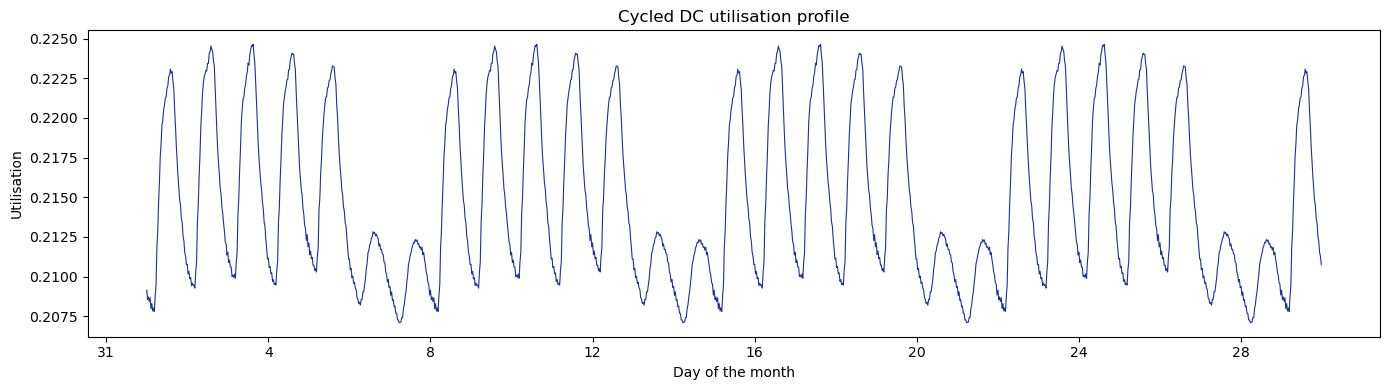

In [ ]:
# get the reference profile
reference = _build_dc_reference_profile()

# get the target snapshot
target = pd.date_range("2030-04-01", "2030-04-29 23:30", freq="30min", tz="UTC")
target_key = pd.MultiIndex.from_arrays(
    [target.dayofweek, target.hour, target.minute],
    names=["dayofweek", "hour", "minute"]
)

# match the reference profile to target, reindexed 
cycled = pd.Series(reference.reindex(target_key).values, index=target)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(cycled.index, cycled.values, linewidth=0.8, color="#1D3299")

ax.set_title("Cycled DC utilisation profile")
ax.set_ylabel("Utilisation")
ax.set_xlabel("Day of the month")
ax.xaxis.get_offset_text().set_visible(False)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%-d'))
plt.tight_layout(); plt.show()

#### **Add DC as Load**

In [43]:
def add_dc_as_load(base_network: pypsa.Network,
                   buses: list,
                   dc_demand_mw: pd.DataFrame,
                   carrier: str = "Data Centre",
                   logger: Optional[logging.Logger] = None) -> pypsa.Network:
    '''
    Add data centres as simple Load components (no flexibility).

    Args:
        n: PyPSA network
        buses: List of bus names
        dc_demand_mw: Data centre demand time series (MW) with bus columns
        carrier: Carrier name for the loads
        logger: Logger instance

    Returns:
        Network with data centre loads added
    '''
    
    if logger:
        logger.info("Adding data centres as Load components (no flexibility)...")
    
    if carrier not in base_network.carriers.index:
        base_network.add("Carrier", carrier)
    
    for bus in buses:
        if bus in dc_demand_mw.columns:
            
            load_name = f"{bus} Data Centre"
            base_network.add("Load",
                             load_name,
                             bus=bus,
                             carrier=carrier,
                             p_set=dc_demand_mw[bus],
                             overwrite=True)

    if logger:
        logger.info(f"Added {len(buses)} data centre loads")

    return base_network

---
---
## <span style=color:aqua> **FLEXIBILITY**
---
---


### **Demand-Side Management (DSM)**

#### **Adding TEMPORAL & SPATIAL**

In [ ]:
def add_dc_temporal_flexibility(base_network: pypsa.Network,
                                  buses: list,
                                  dc_demand_timeseries_mw: pd.DataFrame,
                                  shift_fraction: float = 0.10,
                                  carrier: str = "DSM") -> pd.Series:
    '''
    Function mirroring the 24/7CFE (Riepin et al.) approach to temporal load shifting of the load.
    '''

    if carrier not in base_network.carriers.index:
        base_network.add("Carrier", carrier)
    
    for bus in buses:
        # skip if bus not a data centre bus
        if bus not in dc_demand_timeseries_mw.columns:
            continue
        
        # add the buffer bus which will allow for temporal storage of time delays in and out
        base_network.add("Bus", f"{bus} DSM", carrier=carrier,
                         x=base_network.buses.at[bus, "x"],
                         y=base_network.buses.at[bus, "y"], 
                         overwrite=True)
        
        # Store
        base_network.add("Store", f"{bus} DSM",
                         bus=f"{bus} DSM", 
                         carrier=carrier,
                         e_cyclic=True, # end state = start state
                         e_nom=1e6, # allowable nominal energy storage = 1M MWh = 1k GWh
                         p_nom_extendable=False, # fixed, not extendable p_nom capacity / Store's size
                         overwrite=True) 
        
        # DC -> Buffer (delay IN) & Buffer -> DC (delay OUT) links
        base_network.add("Link", f"{bus} DSM-delayIN", 
                        bus0=bus,
                        bus1=f"{bus} DSM", 
                        carrier=carrier, 
                        efficiency=1, 
                        p_nom=1e6, 
                        marginal_cost=1e-5,
                        p_nom_extendable=False,
                        overwrite=True)
        
        base_network.add("Link", 
                         f"{bus} DSM-delayOUT", 
                         bus0=f"{bus} DSM", 
                         bus1=bus, 
                         carrier=carrier, 
                         efficiency=1, 
                         p_nom=1e6, 
                         marginal_cost=1e-5,
                         p_nom_extendable=False, 
                         overwrite=True)

    return base_network

def add_dc_spatial_flexibility(base_network: pypsa.Network,
                               buses: list,
                               carrier: str = "Virtual Link") -> pypsa.Network:
    
    '''
    Similarly to tmeporal flexibility - approach fully based on Riepin et al.'s paper.
    '''

    if carrier not in base_network.carriers.index:
        base_network.add("Carrier", carrier)

    # vectorised version of the nested for loop from 24/7 CFE paper
    # in case of using networks with more buses
    bus_pairs = list(permutations(buses, 2))
    bus0, bus1 = zip(*bus_pairs)
    link_names = [f"VCC {b0}-{b1}" for b0, b1 in bus_pairs]

    base_network.add("Link", link_names,
                     bus0=list(bus0),
                     bus1=list(bus1),
                     carrier=carrier,
                     marginal_cost=1e-5,
                     p_nom=1e6
    )

    return base_network

### **Temporal shifting:** 
**Daily balance = 0 & delay_out-delay_in must be within the flexibility range**

In [ ]:
def temporal_flexibility_constraints(network,
                                     snapshots,
                                     buses: list,
                                     flexibility_fraction: float = 0.10,
                                     load_name_suffix: str = " Data Centre"):
    '''
    Using the 247CFE approach for constraints etc.
    Based on Riepin et al.'s approach.
    '''
    delta = flexibility_fraction

    def DSM_constraints(network: pypsa.Network, snapshots):
        '''
        Received/sent shifts must sit within the allowable +/- delta range.
        Based on Riepin et al.'s approach.
        '''
        dsm = network.links[network.links.carrier == "DSM"]
        
        for bus in buses:
            load_name = f"{bus}{load_name_suffix}"
            if load_name not in network.loads_t.p_set.columns:
                continue
            
            delay_in_idx = dsm.query("bus0 == @bus").index
            delay_out_idx = dsm.query("bus1 == @bus").index
            if delay_in_idx.empty or delay_out_idx.empty:
                continue
            
            delay_in = network.model["Link-p"].loc[:, delay_in_idx].sum(dims=["name"])
            delay_out = network.model["Link-p"].loc[:, delay_out_idx].sum(dims=["name"])

            load = network.loads_t.p_set[load_name]
            rhs_upper = load * (1+delta) - load
            rhs_lower = load * (1-delta) - load

            network.model.add_constraints(
                delay_out - delay_in <= rhs_upper, name=f"DSM-upper_{bus}"
            )
            network.model.add_constraints(
                delay_out - delay_in >= rhs_lower, name=f"DSM-lower_{bus}"
            )

    def DSM_daily_balance(network: pypsa.Network,
                          snapshots):
        '''
        Implementing the temporal flexibility's daily balance = 0.
        Based on Riepin et al.'s approach.
        '''
        dsm = network.links[network.links.carrier == "DSM"]

        for bus in buses:
            delay_in_idx = dsm.query("bus0 == @bus").index
            delay_out_idx = dsm.query("bus1 == @bus").index
            if delay_in_idx.empty or delay_out_idx.empty:
                continue

            delay_in = network.model["Link-p"].loc[:, delay_in_idx].sum(dims=["name"])
            delay_out = network.model["Link-p"].loc[:, delay_out_idx].sum(dims=["name"])

            daily_in = delay_in.groupby("snapshot.dayofyear").sum()
            daily_out = delay_out.groupby("snapshot.dayofyear").sum()

            network.model.add_constraints(
                daily_out - daily_in == 0, name=f"DSM-conservation_{bus}"
            )  

    DSM_constraints(network, snapshots)
    DSM_daily_balance(network, snapshots)


In [ ]:
def virtual_link_constraints(network: pypsa.Network,
                             snapshots,
                             buses: list,
                             flexibility_fraction: float = 0.10,
                             load_name_suffix: str = " Data Centre",
                             carrier: str = "Virtual Link"):
    
    '''Function based on the Riepin et al.'s approach'''

    delta = flexibility_fraction
    vls = network.links[network.links.carrier == carrier]

    for bus in buses:
        load_name = f"{bus}{load_name_suffix}"
        if load_name not in network.loads_t.p_set.columns:
             continue
        sent_idx = vls.query("bus0==@bus").index
        received_idx = vls.query("bus1==@bus").index

        if sent_idx.empty and received_idx.empty:
             continue
        
        sent = network.model["Link-p"].loc[:, sent_idx].sum(dims=["name"]) if not sent_idx.empty else 0
        received = network.model["Link-p"].loc[:, received_idx].sum(dims=["name"]) if not received_idx.empty else 0
        load = network.loads_t.p_set[load_name]

        rhs_upper = load * (1+delta) - load
        rhs_lower = load * (1-delta) - load

        network.model.add_constraints(received-sent <= rhs_upper, name=f"vl_limit-upper_{bus}")
        network.model.add_constraints(received-sent >= rhs_lower, name=f"vl_limit-lower_{bus}")

def temporal_plus_spatial_constraints(network: pypsa.Network,
                                      snapshots,
                             buses: list,
                             flexibility_fraction: float = 0.10,
                             load_name_suffix: str = " Data Centre",
                             vl_carrier: str = "Virtual Link",
                             dsm_carrier: str = "DSM"):
    
    '''Function based on the Riepin et al.'s approach'''

    delta = flexibility_fraction
    vls = network.links[network.links.carrier == vl_carrier]
    dsm = network.links[network.links.carrier == dsm_carrier]

    for bus in buses:
        load_name = f"{bus}{load_name_suffix}"
        if load_name not in network.loads_t.p_set.columns:
            continue

        sent_idx = vls.query("bus0==@bus").index
        received_idx = vls.query("bus1==@bus").index
        delay_in_idx = dsm.query("bus0==@bus").index
        delay_out_idx = dsm.query("bus1==@bus").index
        
        if sent_idx.empty and received_idx.empty:
            continue    
            
        sent = network.model["Link-p"].loc[:, sent_idx].sum(dims=["name"]) if not sent_idx.empty else 0
        received = network.model["Link-p"].loc[:, received_idx].sum(dims=["name"]) if not received_idx.empty else 0
        delay_in = network.model["Link-p"].loc[:,delay_in_idx].sum(dims=["name"]) if not delay_in_idx.empty else 0
        delay_out = network.model["Link-p"].loc[:,delay_out_idx].sum(dims=["name"]) if not delay_out_idx.empty else 0

        load = network.loads_t.p_set[load_name]
        rhs_upper = load * (1+delta) - load
        rhs_lower = load * (1-delta) - load

        combined = (received-sent) + (delay_out-delay_in)

        network.model.add_constraints(combined<=rhs_upper, name=f"LoadShift-upper_{bus}")
        network.model.add_constraints(combined>=rhs_lower, name=f"LoadShift-lower_{bus}")

def cfe_constraint_simplified(network: pypsa.Network,
                              snapshots, 
                                  buses, 
                                  load_name_suffix = " Data Centre",
                                  clean_tech_carriers=('large_hydro', 'marine', 'solar_pv', 'wind_offshore',
                                                'wind_onshore'),
                                  clean_eu_carrier='EU_import',
                                  clean_eu_imports_fraction=0.3,
                                  storage_carriers=None,
                                  x_cfe=0.03):
    '''
    A simplified version of the mirrored 24/7 CFE approach for applying the clean energy constraint. The constrained is applied per-snapshot,
    but the EU import CFE-score is constant, based on assumption, rather than verified & variable.
    Args:
        - base_network: pypsa network
        - buses: the data centre buses
        - load_name_suffix: the searchable part to create a per-bus full load_name: "{bus} Data Centre"
        - clean_tech_carriers: selected "acceptable" carriers for green energy
        - clean_eu_carrier: the EU imports carrier
        - clean_eu_imports_fraction: the assumed fraction of imported energy that's green
    Returns:
        nothing, just adds constraints to the run
    '''
 
    # for every bus data centre is on, create a load_name
    for bus in buses:
        load_name = f"{bus}{load_name_suffix}"
        if load_name not in network.loads_t.p_set.columns:
            continue

        # eligible clean_generators are those data centres are on, AND their carrier is one of the specified clean carriers
        clean_generators = network.generators.index[(network.generators.bus == bus) & network.generators.carrier.isin(clean_tech_carriers)]
        
        print(f"Clean generators: {clean_generators}")
        eu_import = network.generators.index[(network.generators.bus == bus) & (network.generators.carrier == clean_eu_carrier)]
        print(f"EU import: {eu_import}")

        storage = network.storage_units.index[network.storage_units.bus == bus]
        if storage_carriers is not None:
            storage = storage[network.storage_units.loc[storage, "carrier"].isin(storage_carriers)]

        # sum the eligible generators; if none -> 0
        clean_generators_sum = network.model["Generator-p"].loc[:, clean_generators].sum(dims=["name"]) if len(clean_generators) else 0
        eu_import_sum = network.model["Generator-p"].loc[:, eu_import].sum(dims=["name"]) if len(eu_import) else 0
        storage_discharge_sum = network.model["StorageUnit-p_dispatch"].loc[:,storage].sum(dims=["name"]) if len(storage) else 0
        storage_charge_sum = network.model["StorageUnit-p_store"].loc[:,storage].sum(dims=["name"]) if len(storage) else 0
        print(f"Sums: {clean_generators_sum}, {eu_import_sum}, {storage_discharge_sum}, {storage_charge_sum}")
        load = network.loads_t.p_set[load_name]

        lhs = clean_generators_sum + eu_import_sum * clean_eu_imports_fraction + storage_discharge_sum - storage_charge_sum
        rhs = x_cfe * load

        network.model.add_constraints(lhs >= rhs, name=f"CleanEnergy_{bus}")


### **Function for tests**

In [ ]:
NETWORK_PATHS = {
    "Q1_zonal_2020": "../resources/network/Martas_Q1_zonal_2020.nc",
    "Q2_zonal_2020": "../resources/network/Martas_Q2_zonal_2020.nc",
    "Q3_zonal_2020": "../resources/network/Martas_Q3_zonal_2020.nc",
    "Q4_zonal_2020": "../resources/network/Martas_Q4_zonal_2020.nc",
    "Q1_reduced_2030": "../resources/network/Martas_Q1_reduced_2030.nc",
    "Q2_reduced_2030": "../resources/network/Martas_Q2_reduced_2030.nc",
    "Q3_reduced_2030": "../resources/network/Martas_Q3_reduced_2030.nc",
    "Q4_reduced_2030": "../resources/network/Martas_Q4_reduced_2030.nc",
    "Jan_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Jan.nc",
    "Nov_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Nov.nc",
    "Aug_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Aug.nc",
    "Apr_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Apr.nc",
    "HT35_flex": "../resources/network/HT35_flex.nc",
}


def run_flexibility_test(network_name="Q1_zonal_2020", dc_allocation=1, total_dc_gw=4,
             flexibility_fraction=0.1, mode="temporal", return_inflexible=False, x_cfe=0.03):
    '''
    mode: "temporal", "spatial", or "both" — controls which flexibility
    mechanism(s) are built and which extra_functionality is used.
    '''
    if network_name not in NETWORK_PATHS:
        raise ValueError(f"Unknown network_name '{network_name}'. Choose from: {list(NETWORK_PATHS.keys())}")
    test_network = pypsa.Network(NETWORK_PATHS[network_name]).copy()
    # Q1
    # test_network.set_snapshots(
    #     test_network.snapshots[
    #         (test_network.snapshots >= "2030-01-01") & (test_network.snapshots <= "2030-03-31")
    #     ]
    # )

    # Q2
    # test_network.set_snapshots(
    #     test_network.snapshots[
    #         (test_network.snapshots >= "2030-04-01") & (test_network.snapshots <= "2030-06-30")
    #     ]
    # )

    # Q3
    test_network.set_snapshots(
            test_network.snapshots[
                (test_network.snapshots >= "2030-07-01") & (test_network.snapshots <= "2030-09-30")
            ]
        )
    
    # Q4
    # test_network.set_snapshots(
    #     test_network.snapshots[
    #         (test_network.snapshots >= "2030-10-01") & (test_network.snapshots <= "2030-12-31")
    #     ]
    # )

    reference = _build_dc_reference_profile()
    key = pd.MultiIndex.from_arrays(
        [test_network.snapshots.dayofweek, test_network.snapshots.hour, test_network.snapshots.minute],
        names=["dayofweek", "hour", "minute"]
    )
    missing_keys = key[~key.isin(reference.index)]
    print(missing_keys.unique())
    
    if dc_allocation == 0:
        dc_allocation = allocate_current_split_scaled(total_dc_gw=total_dc_gw, base_network=test_network, logger = logging.Logger)
        dc_allocation_selected = "current"
    
    elif dc_allocation == 1:
        dc_allocation = allocate_population_density_weighted(total_dc_gw=total_dc_gw, base_network=test_network, logger = logging.Logger)
        dc_allocation_selected = "population"
    
    elif dc_allocation == 2:
        dc_allocation = allocate_north_scotland(total_dc_gw=total_dc_gw, base_network=test_network, logger = logging.Logger)
        dc_allocation_selected = "scotland"

    buses = dc_allocation[dc_allocation > 0].index.tolist() # selected buses where dc were added
    print(f"Buses: {buses}")
    dc_demand_timeseries_mw = _get_dc_demand_mw_timeseries(dc_allocation=dc_allocation, network=test_network)
    
    test_network = add_dc_as_load(base_network = test_network, buses=buses, dc_demand_mw=dc_demand_timeseries_mw)
    missing = [b for b in buses if b not in test_network.buses.index]
    print("Missing buses:", missing)
    print(test_network.snapshots.min(), test_network.snapshots.max())
    flexible_network = test_network.copy()
    test_network.export_to_netcdf(f"../notebooks/results/networks/test_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}.nc")
    if return_inflexible:
        test_network.optimize(solver_name="gurobi", solver_options={"Method":2})
        test_network.export_to_netcdf(f"../notebooks/results/networks/test_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_solved.nc")
        del test_network.model
        gc.collect()
    

    if mode == "temporal":
        flexible_network = add_dc_temporal_flexibility(base_network = flexible_network, buses=buses, dc_demand_timeseries_mw=dc_demand_timeseries_mw)
        def dsm_extra_functionality(base_network, snapshots):
            temporal_flexibility_constraints(base_network, snapshots, buses=buses, flexibility_fraction=flexibility_fraction)

        flexible_network.export_to_netcdf(f"../notebooks/results/networks/flexible_{mode}_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_flex-{flexibility_fraction}.nc")
        flexible_network.optimize(solver_name="gurobi", extra_functionality=dsm_extra_functionality, solver_options={"Method":2})
        flexible_network.export_to_netcdf(f"../notebooks/results/networks/flexible_{mode}_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_flex-{flexibility_fraction}_solved.nc")

        del flexible_network.model
        gc.collect()

    elif mode == "spatial":
        flexible_network = add_dc_spatial_flexibility(base_network = flexible_network, buses=buses)
        def vl_extra_functionality(base_network, snapshots):
            virtual_link_constraints(base_network, snapshots, buses=buses, flexibility_fraction=flexibility_fraction)

        flexible_network.export_to_netcdf(f"../notebooks/results/networks/flexible_{mode}_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_flex-{flexibility_fraction}.nc")
        flexible_network.optimize(solver_name="gurobi", extra_functionality=vl_extra_functionality, solver_options={"Method":2})
        flexible_network.export_to_netcdf(f"../notebooks/results/networks/flexible_{mode}_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_flex-{flexibility_fraction}_solved.nc")

        del flexible_network.model
        gc.collect()

    elif mode == "both":
        flexible_network = add_dc_spatial_flexibility(base_network = flexible_network, buses=buses)
        flexible_network = add_dc_temporal_flexibility(base_network = flexible_network, buses=buses, dc_demand_timeseries_mw=dc_demand_timeseries_mw)

        def both_extra_functionality(base_network, snapshots):
            temporal_plus_spatial_constraints(base_network, snapshots, buses=buses, flexibility_fraction=flexibility_fraction)

        flexible_network.export_to_netcdf(f"../notebooks/results/networks/flexible_{mode}_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_flex-{flexibility_fraction}.nc")
        flexible_network.optimize(solver_name="gurobi", extra_functionality=both_extra_functionality, solver_options={"Method":2})
        flexible_network.export_to_netcdf(f"../notebooks/results/networks/flexible_{mode}_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_flex-{flexibility_fraction}_solved.nc")

        del flexible_network.model
        gc.collect()

    elif mode == "cfe_both":
        flexible_network = add_dc_spatial_flexibility(base_network = flexible_network, buses=buses)
        flexible_network = add_dc_temporal_flexibility(base_network = flexible_network, buses=buses, dc_demand_timeseries_mw=dc_demand_timeseries_mw)
        
        def cfe_both_extra_functionality(base_network, snapshots):
            temporal_plus_spatial_constraints(base_network, snapshots, buses=buses, flexibility_fraction=flexibility_fraction)
            cfe_constraint_simplified(base_network, snapshots, buses=buses,x_cfe=x_cfe)

        flexible_network.export_to_netcdf(f"../notebooks/results/networks/flexible_{mode}_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_flex-{flexibility_fraction}_x_cfe-{x_cfe}.nc")
        flexible_network.optimize(solver_name="gurobi", extra_functionality=cfe_both_extra_functionality, solver_options={"Method":2})
        flexible_network.export_to_netcdf(f"../notebooks/results/networks/flexible_{mode}_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_flex-{flexibility_fraction}_x_cfe-{x_cfe}_solved.nc")
        print(list(flexible_network.model.variables))
        del flexible_network.model
        gc.collect()

    elif mode == "cfe":
        def cfe_extra_functionality(base_network, snapshots):
            cfe_constraint_simplified(base_network, snapshots, buses=buses,x_cfe=x_cfe)

        flexible_network.export_to_netcdf(f"../notebooks/results/networks/inflexible_{mode}_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_flex-{flexibility_fraction}_x_cfe-{x_cfe}.nc")
        flexible_network.optimize(solver_name="gurobi", extra_functionality=cfe_extra_functionality, solver_options={"Method":2})
        flexible_network.export_to_netcdf(f"../notebooks/results/networks/inflexible_{mode}_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_flex-{flexibility_fraction}_x_cfe-{x_cfe}_solved.nc")
        print(list(flexible_network.model.variables))
        del flexible_network.model
        gc.collect()

    else:
        print("Inflexible Data Centre mode")
    
    if return_inflexible:
        return test_network, flexible_network
    else:
        return flexible_network

In [ ]:
# POPULATION, 4GW, flex=0.4 - example run
capacity = 4
allocation = 1
flex = 0.4
x_cfe=1

run_flexibility_test(network_name="Q3_reduced_2030", dc_allocation=allocation, total_dc_gw=capacity,
             flexibility_fraction=flex, return_inflexible=True)
run_flexibility_test(network_name="Q3_reduced_2030", dc_allocation=allocation, total_dc_gw=capacity,
             flexibility_fraction=flex, mode="spatial")
run_flexibility_test(network_name="Q3_reduced_2030", dc_allocation=allocation, total_dc_gw=capacity,
             flexibility_fraction=flex, mode="both")
run_flexibility_test(network_name="Q3_reduced_2030", dc_allocation=allocation, total_dc_gw=capacity,
             flexibility_fraction=flex, mode="cfe",x_cfe=x_cfe)
run_flexibility_test(network_name="Q3_reduced_2030", dc_allocation=allocation, total_dc_gw=capacity,
             flexibility_fraction=flex, mode="cfe_both",x_cfe=x_cfe)

INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'Martas_Q3_reduced_2030 (Full)' has buses, carriers, generators, lines, links, loads, storage_units, stores


MultiIndex([], names=['dayofweek', 'hour', 'minute'])
Allocated 3999.97 MW population-weighted across the (13 DCs of 307.69 MW).
Buses: ['Neilston', 'Penwortham', 'Deeside', 'Daines', 'Thornton/Drax/Eggborough', 'Ratcliffe', 'Feckenham', 'Pelham', 'Sundon/East Claydon', 'Bramley', 'London', 'Kemsley', 'Lovedean']
Missing buses: []
2030-07-01 00:00:00 2030-09-30 00:00:00


INFO:pypsa.network.io:Exported network 'Martas_Q3_reduced_2030 (Full)' saved to '../notebooks/results/networks/test_net-Q3_reduced_2030_dc_allo-population_total-4.nc contains: links, loads, stores, lines, buses, generators, storage_units, carriers
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_50390/2335019768.py:86: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  test_network.optimize(solver_name="gurobi", solver_options={"Method":2})
Index(['16'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - Method: 2
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 13.27it/s]
INFO:linopy.io: Writing time: 7.02s


Set parameter Username


INFO:gurobipy:Set parameter Username


...

INFO:gurobipy:Solved in 3342007 iterations and 599.14 seconds (820.71 work units)


Optimal objective  7.828443348e+07


INFO:gurobipy:Optimal objective  7.828443348e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 11396960 primals, 24834710 duals
Objective: 7.83e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance, Store-energy_balance, LoadShift-upper_Neilston, LoadShift-lower_Neilston, LoadShift-upper_Penwortham, LoadShift-lower_Penwortham, LoadShift-upper_Deeside, LoadShift-lower_Deeside, LoadShift-upper_Daines, LoadShift-lower_Daines, LoadShift-upper_Thornton/Drax/Eggborough,

['Generator-p', 'Line-s', 'Link-p', 'Store-e', 'StorageUnit-p_dispatch', 'StorageUnit-p_store', 'StorageUnit-state_of_charge', 'Store-p']


PyPSA Network 'Martas_Q3_reduced_2030 (Full)'
---------------------------------------------
Components:
 - Bus: 52
 - Carrier: 91
 - Generator: 2303
 - Line: 99
 - Link: 428
 - Load: 42
 - StorageUnit: 786
 - Store: 14
 - SubNetwork: 1
Snapshots: 2185

In [ ]:
allocation = "population"   
x_cfe = 1
flex = 0.4
n1=pypsa.Network(f'../notebooks/results/networks/test_net-Q3_reduced_2030_dc_allo-{allocation}_total-4_solved.nc')
n2=pypsa.Network(f'../notebooks/results/networks/flexible_temporal_net-Q3_reduced_2030_dc_allo-{allocation}_total-4_flex-{flex}_solved.nc')
n3=pypsa.Network(f'../notebooks/results/networks/flexible_spatial_net-Q3_reduced_2030_dc_allo-{allocation}_total-4_flex-{flex}_solved.nc')
n4=pypsa.Network(f'../notebooks/results/networks/flexible_both_net-Q3_reduced_2030_dc_allo-{allocation}_total-4_flex-{flex}_solved.nc')
n5=pypsa.Network(f'../notebooks/results/networks/inflexible_cfe_net-Q3_reduced_2030_dc_allo-{allocation}_total-4_flex-{flex}_x_cfe-1_solved.nc')
n6=pypsa.Network(f'../notebooks/results/networks/flexible_cfe_both_net-Q3_reduced_2030_dc_allo-{allocation}_total-4_flex-{flex}_x_cfe-1_solved.nc')


INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'Martas_Q3_reduced_2030 (Full)' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'Martas_Q3_reduced_2030 (Full)' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'Martas_Q3_reduced_2030 (Full)' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'Martas_Q3_reduced_2030 (Full)' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.netwo

In [55]:
print(n1.objective)
print(n2.objective)
print(n3.objective)
print(n4.objective)
print(n5.objective)
print(n6.objective)

83006417.42261532
81454380.7564956
83005919.86478516
77624801.0693362
83697462.61746173
78284433.4753246


In [61]:
# n1.statistics()
# n2.statistics()
# n3.statistics()
# n4.statistics()
# n5.statistics()
n6.statistics()


Optimal Capacity  \
Generator   Advanced Biofuel                     3.724393e+02   
            Biogas                               1.642892e+03   
            Biomass                              9.185807e+03   
            Combined Cycle Gas Turbine           2.358600e+04   
            Combined Heat & Power                3.534036e+03   
            European Imports                     1.369500e+04   
            Gas Engine                           4.067294e+03   
            Geothermal                           1.100000e+01   
            Landfill Gas                         8.345111e+02   
            Large Hydro                          1.897296e+03   
            Load Shedding                        4.862919e+04   
            Marine Energy                        2.543580e+02   
            Nuclear                              4.570000e+03   
            Offshore Wind                        5.354420e+04   
            Oil                                  7.850000e+01   
            Onshore Wind                         2.727074e+04   
            Open Cycle Gas Turbine               3.662890e+03   
            Sewage Gas                           5.581939e+01   
            Solar PV                             4.047042e+04   
            Waste to Energy                      4.643178e+03   
Line        AC                                   2.308000e+05   
Link        DC                                   1.245000e+04   
            DSM                                  2.600000e+07   
            Electrolysis                         3.653095e+03   
            H2 Power Generation                  2.783810e+02   
            Virtual Link                         1.560000e+08   
Load        Data Centre                          0.000000e+00   
            Electricity                          0.000000e+00   
StorageUnit Battery Storage                      2.647197e+04   
            Domestic Battery Storage             8.577080e+02   
            Liquid Air Energy Storage            4.579940e+02   
            Pumped Storage Hydroelectricity      5.300000e+03   
Store       DSM                                  1.300000e+07   
            Hydrogen Gas                         4.676801e+04   

                                             Installed Capacity        Supply  \
Generator   Advanced Biofuel                       3.724393e+02  0.000000e+00   
            Biogas                                 1.642892e+03  0.000000e+00   
            Biomass                                9.185807e+03  0.000000e+00   
            Combined Cycle Gas Turbine             2.358600e+04  0.000000e+00   
            Combined Heat & Power                  3.534036e+03  0.000000e+00   
            European Imports                       1.369500e+04  3.411074e+06   
            Gas Engine                             4.067294e+03  0.000000e+00   
            Geothermal                             1.100000e+01  4.074988e+03   
            Landfill Gas                           8.345111e+02  3.558208e+01   
            Large Hydro                            1.897296e+03  1.371387e+06   
            Load Shedding                          4.862919e+04  0.000000e+00   
            Marine Energy                          2.543580e+02  2.343247e+05   
            Nuclear                                4.570000e+03  3.998908e+06   
            Offshore Wind                          5.354420e+04  2.488465e+07   
            Oil                                    7.850000e+01  0.000000e+00   
            Onshore Wind                           2.727074e+04  1.107898e+07   
            Open Cycle Gas Turbine                 3.662890e+03  0.000000e+00   
            Sewage Gas                             5.581939e+01  0.000000e+00   
            Solar PV                               4.047042e+04  1.343155e+07   
            Waste to Energy                        4.643178e+03  0.000000e+00   
Line        AC                                     2.308000e+05  3.1